<a href="https://colab.research.google.com/github/2403a52276-ctrl/AIAC/blob/main/ML_Assignment_10__2403A52276_Batch_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the train.csv file into a pandas DataFrame
df = pd.read_csv('/content/train.csv')

# Sele ct the 'GrLivArea' and 'SalePrice' columns
selected_data = df[['GrLivArea', 'SalePrice']]

# Display the first 5 rows of the selected data
display(selected_data.head())

,GrLivArea,SalePrice
0,1710,208500
1,1262,181500
2,1786,223500
3,1717,140000
4,2198,250000


In [3]:
from sklearn.linear_model import LinearRegression

# Reshape the independent variable (GrLivArea) to be 2D
X = selected_data[['GrLivArea']]
y = selected_data['SalePrice']

# Initialize and fit the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Get the coefficient β₁
beta_1 = model.coef_[0]

print(f"Coefficient β₁ (GrLivArea): {beta_1:.2f}")

Coefficient β₁ (GrLivArea): 107.13


In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Number of bootstrap samples
B = 1000

# List to store bootstrap coefficients
beta_1_bootstrap_samples = []

# Perform bootstrap resampling
for _ in range(B):
    # Sample with replacement from the original data
    df_bootstrap = selected_data.sample(n=len(selected_data), replace=True)

    # Prepare X and y for the bootstrap sample
    X_bootstrap = df_bootstrap[['GrLivArea']]
    y_bootstrap = df_bootstrap['SalePrice']

    # Initialize and fit the Linear Regression model on the bootstrap sample
    model_bootstrap = LinearRegression()
    model_bootstrap.fit(X_bootstrap, y_bootstrap)

    # Store the coefficient β₁
    beta_1_bootstrap_samples.append(model_bootstrap.coef_[0])

print(f"Collected {len(beta_1_bootstrap_samples)} bootstrap samples of β₁.")
# You can now analyze beta_1_bootstrap_samples, e.g., calculate mean, std, plot histogram

Collected 1000 bootstrap samples of β₁.


In [5]:
# Compute the 95% confidence interval for β₁ using the percentile method
# This involves finding the 2.5th and 97.5th percentiles of the bootstrap samples

# Ensure numpy is imported for percentile calculation, though it should be from the previous cell.
import numpy as np

lower_bound = np.percentile(beta_1_bootstrap_samples, 2.5)
upper_bound = np.percentile(beta_1_bootstrap_samples, 97.5)

print(f"95% Confidence Interval for β₁: ({lower_bound:.2f}, {upper_bound:.2f})")

95% Confidence Interval for β₁: (93.05, 120.04)


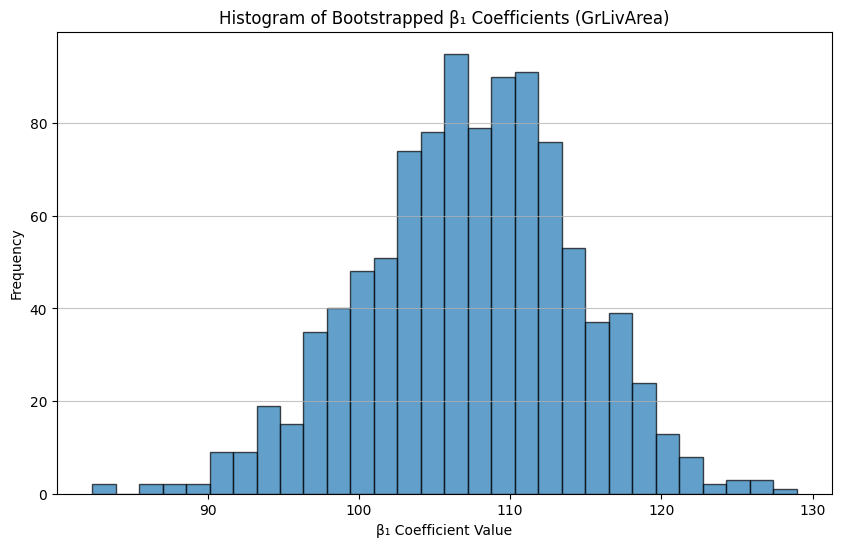

In [6]:
import matplotlib.pyplot as plt

# Plotting the histogram of bootstrapped β₁ values
plt.figure(figsize=(10, 6))
plt.hist(beta_1_bootstrap_samples, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Bootstrapped β₁ Coefficients (GrLivArea)')
plt.xlabel('β₁ Coefficient Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [7]:
import pandas as pd

# Load the insurance.csv dataset
insurance_df = pd.read_csv('/content/insurance.csv')

# Identify categorical columns for one-hot encoding
categorical_cols = insurance_df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
insurance_encoded_df = pd.get_dummies(insurance_df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the new DataFrame with encoded variables
print("Original DataFrame head:")
display(insurance_df.head())

print("\nDataFrame after One-Hot Encoding head:")
display(insurance_encoded_df.head())

print(f"Original DataFrame shape: {insurance_df.shape}")
print(f"Encoded DataFrame shape: {insurance_encoded_df.shape}")

Original DataFrame head:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



DataFrame after One-Hot Encoding head:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Original DataFrame shape: (1338, 7)
Encoded DataFrame shape: (1338, 9)


In [8]:
from sklearn.linear_model import LinearRegression

# Select 'bmi' as the feature (X) and 'charges' as the target (y)
X_insurance = insurance_encoded_df[['bmi']]
y_insurance = insurance_encoded_df['charges']

# Initialize and fit the Linear Regression model
model_insurance = LinearRegression()
model_insurance.fit(X_insurance, y_insurance)

# Get the coefficient for 'bmi'
beta_bmi = model_insurance.coef_[0]

print(f"Coefficient for BMI (β₁): {beta_bmi:.2f}")

Coefficient for BMI (β₁): 393.87


In [9]:
from sklearn.linear_model import LinearRegression

# Select 'bmi' as the feature (X) and 'charges' as the target (y)
X_insurance = insurance_encoded_df[['bmi']]
y_insurance = insurance_encoded_df['charges']

# Initialize and fit the Linear Regression model
model_insurance = LinearRegression()
model_insurance.fit(X_insurance, y_insurance)

# Get the coefficient for 'bmi'
beta_bmi = model_insurance.coef_[0]

print(f"Coefficient for BMI (β₁): {beta_bmi:.2f}")

Coefficient for BMI (β₁): 393.87


In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Number of bootstrap samples
B = 2000

# List to store bootstrap coefficients for BMI
beta_bmi_bootstrap_samples = []

# Perform bootstrap resampling
for _ in range(B):
    # Sample with replacement from the encoded insurance data
    df_bootstrap_insurance = insurance_encoded_df.sample(n=len(insurance_encoded_df), replace=True)

    # Prepare X and y for the bootstrap sample
    X_bootstrap_insurance = df_bootstrap_insurance[['bmi']]
    y_bootstrap_insurance = df_bootstrap_insurance['charges']

    # Initialize and fit the Linear Regression model on the bootstrap sample
    model_bootstrap_insurance = LinearRegression()
    model_bootstrap_insurance.fit(X_bootstrap_insurance, y_bootstrap_insurance)

    # Store the coefficient for BMI
    beta_bmi_bootstrap_samples.append(model_bootstrap_insurance.coef_[0])

print(f"Collected {len(beta_bmi_bootstrap_samples)} bootstrap samples of β₁ (BMI).")

# Compute the 95% confidence interval for β₁ (BMI) using the percentile method
lower_bound_bmi = np.percentile(beta_bmi_bootstrap_samples, 2.5)
upper_bound_bmi = np.percentile(beta_bmi_bootstrap_samples, 97.5)

print(f"95% Confidence Interval for BMI Coefficient (β₁): ({lower_bound_bmi:.2f}, {upper_bound_bmi:.2f})")

Collected 2000 bootstrap samples of β₁ (BMI).
95% Confidence Interval for BMI Coefficient (β₁): (285.56, 504.26)


In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Number of bootstrap samples
B = 2000

# List to store bootstrap coefficients for BMI
beta_bmi_bootstrap_samples = []

# Perform bootstrap resampling
for _ in range(B):
    # Sample with replacement from the encoded insurance data
    df_bootstrap_insurance = insurance_encoded_df.sample(n=len(insurance_encoded_df), replace=True)

    # Prepare X and y for the bootstrap sample
    X_bootstrap_insurance = df_bootstrap_insurance[['bmi']]
    y_bootstrap_insurance = df_bootstrap_insurance['charges']

    # Initialize and fit the Linear Regression model on the bootstrap sample
    model_bootstrap_insurance = LinearRegression()
    model_bootstrap_insurance.fit(X_bootstrap_insurance, y_bootstrap_insurance)

    # Store the coefficient for BMI
    beta_bmi_bootstrap_samples.append(model_bootstrap_insurance.coef_[0])

print(f"Collected {len(beta_bmi_bootstrap_samples)} bootstrap samples of β₁ (BMI).")

# Compute the 95% confidence interval for β₁ (BMI) using the percentile method
lower_bound_bmi = np.percentile(beta_bmi_bootstrap_samples, 2.5)
upper_bound_bmi = np.percentile(beta_bmi_bootstrap_samples, 97.5)

print(f"95% Confidence Interval for BMI Coefficient (β₁): ({lower_bound_bmi:.2f}, {upper_bound_bmi:.2f})")

Collected 2000 bootstrap samples of β₁ (BMI).
95% Confidence Interval for BMI Coefficient (β₁): (286.72, 508.00)


In [15]:
import pandas as pd

# Load the dataset
sales_df = pd.read_csv('/content/Advertising Budget and Sales.csv')

# Print all column names to verify
print("Columns in the dataset:", sales_df.columns.tolist())

# Select 'TV Ad Budget ($)' as the feature (X)
X_sales = sales_df[['TV Ad Budget ($)']]
# Select 'Sales ($)' as the target (y)
y_sales = sales_df['Sales ($)']

print("\nDataset loaded and features/target selected.")
print("First 5 rows of X_sales (TV feature):")
display(X_sales.head())
print("First 5 rows of y_sales (Sales target):")
display(y_sales.head())

Columns in the dataset: ['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Sales ($)']

Dataset loaded and features/target selected.
First 5 rows of X_sales (TV feature):


,TV Ad Budget ($)
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8


First 5 rows of y_sales (Sales target):


,Sales ($)
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [16]:
from sklearn.linear_model import LinearRegression

# Initialize and fit the Linear Regression model
model_sales = LinearRegression()
model_sales.fit(X_sales, y_sales)

# Get the coefficient (slope) for 'TV Ad Budget ($)'
beta_tv_ad_budget = model_sales.coef_[0]

print(f"Coefficient for TV Ad Budget ($) (β₁): {beta_tv_ad_budget:.2f}")

Coefficient for TV Ad Budget ($) (β₁): 0.05


In [17]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Number of bootstrap samples
B = 1000

# List to store bootstrap coefficients for TV Ad Budget
beta_tv_bootstrap_samples = []

# Combine X and y for easier sampling
sales_data_for_bootstrap = X_sales.copy()
sales_data_for_bootstrap['Sales ($)'] = y_sales

# Perform bootstrap resampling
for _ in range(B):
    # Sample with replacement from the combined data
    df_bootstrap_sales = sales_data_for_bootstrap.sample(n=len(sales_data_for_bootstrap), replace=True)

    # Prepare X and y for the bootstrap sample
    X_bootstrap_sales = df_bootstrap_sales[['TV Ad Budget ($)']]
    y_bootstrap_sales = df_bootstrap_sales['Sales ($)']

    # Initialize and fit the Linear Regression model on the bootstrap sample
    model_bootstrap_sales = LinearRegression()
    model_bootstrap_sales.fit(X_bootstrap_sales, y_bootstrap_sales)

    # Store the coefficient for TV Ad Budget
    beta_tv_bootstrap_samples.append(model_bootstrap_sales.coef_[0])

print(f"Collected {len(beta_tv_bootstrap_samples)} bootstrap samples of β₁ (TV Ad Budget).")

# Compute the mean of the bootstrap coefficients
mean_beta_tv = np.mean(beta_tv_bootstrap_samples)

print(f"Mean of Bootstrapped β₁ (TV Ad Budget): {mean_beta_tv:.2f}")

Collected 1000 bootstrap samples of β₁ (TV Ad Budget).
Mean of Bootstrapped β₁ (TV Ad Budget): 0.05


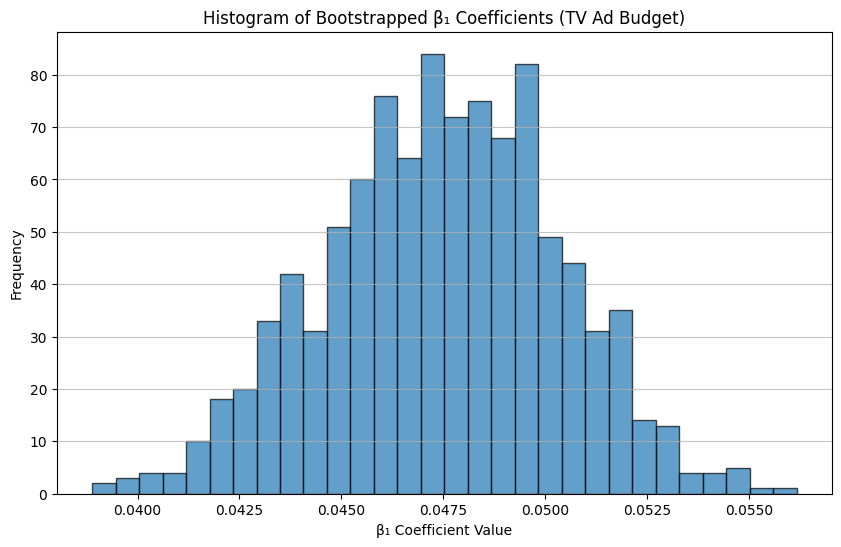

In [18]:
import matplotlib.pyplot as plt

# Plotting the histogram of bootstrapped β₁ values for TV Ad Budget
plt.figure(figsize=(10, 6))
plt.hist(beta_tv_bootstrap_samples, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Bootstrapped β₁ Coefficients (TV Ad Budget)')
plt.xlabel('β₁ Coefficient Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [19]:
import numpy as np
import statsmodels.api as sm

# 1. Compute the 95% confidence interval for β₁ (TV Ad Budget) using the percentile method from bootstrap samples
# beta_tv_bootstrap_samples is available from cell TAzIE01zI99s
lower_bound_bootstrap_tv = np.percentile(beta_tv_bootstrap_samples, 2.5)
upper_bound_bootstrap_tv = np.percentile(beta_tv_bootstrap_samples, 97.5)

print(f"Bootstrap 95% Confidence Interval for β₁ (TV Ad Budget): ({lower_bound_bootstrap_tv:.4f}, {upper_bound_bootstrap_tv:.4f})")

# 2. Compute the analytical 95% Confidence Interval for β₁ using statsmodels
# X_sales and y_sales are available from cell S9UNJRfuIfJF

# Add a constant to the independent variable for the intercept term required by statsmodels
X_sales_const = sm.add_constant(X_sales)

# Fit the OLS model
model_ols = sm.OLS(y_sales, X_sales_const)
results_ols = model_ols.fit()

# Get the confidence interval for the coefficients
analy_ci_df = results_ols.conf_int(alpha=0.05)

# Extract the CI for the 'TV Ad Budget ($)' coefficient
# The coefficients are ordered as [const, 'TV Ad Budget ($)']
lower_bound_analytical_tv = analy_ci_df.loc['TV Ad Budget ($)', 0]
upper_bound_analytical_tv = analy_ci_df.loc['TV Ad Budget ($)', 1]

print(f"Analytical 95% Confidence Interval for β₁ (TV Ad Budget): ({lower_bound_analytical_tv:.4f}, {upper_bound_analytical_tv:.4f})")

# Comparison
print("\nComparison:")
print(f"Bootstrap CI:  ({lower_bound_bootstrap_tv:.4f}, {upper_bound_bootstrap_tv:.4f})")
print(f"Analytical CI: ({lower_bound_analytical_tv:.4f}, {upper_bound_analytical_tv:.4f})")

Bootstrap 95% Confidence Interval for β₁ (TV Ad Budget): (0.0418, 0.0528)
Analytical 95% Confidence Interval for β₁ (TV Ad Budget): (0.0422, 0.0528)

Comparison:
Bootstrap CI:  (0.0418, 0.0528)
Analytical CI: (0.0422, 0.0528)


In [20]:
import pandas as pd

# Load the dataset
car_price_df = pd.read_csv('/content/CarPrice_Assignment.csv')

# Select 'horsepower' as the feature (X)
X_car = car_price_df[['horsepower']]
# Select 'price' as the target (y)
y_car = car_price_df['price']

print("Dataset loaded and features/target selected.")
print("First 5 rows of X_car (horsepower feature):")
display(X_car.head())
print("First 5 rows of y_car (price target):")
display(y_car.head())

Dataset loaded and features/target selected.
First 5 rows of X_car (horsepower feature):


,horsepower
0,111
1,111
2,154
3,102
4,115


First 5 rows of y_car (price target):


,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0


In [21]:
from sklearn.linear_model import LinearRegression

# Initialize and fit the Linear Regression model
model_car = LinearRegression()
model_car.fit(X_car, y_car)

# Get the coefficient (slope) for 'horsepower'
beta_horsepower = model_car.coef_[0]

print(f"Coefficient for Horsepower (β₁): {beta_horsepower:.2f}")

Coefficient for Horsepower (β₁): 163.26


In [23]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Number of bootstrap samples
B = 1500

# List to store bootstrap coefficients for horsepower
beta_horsepower_bootstrap_samples = []

# Combine X and y for easier sampling
car_data_for_bootstrap = X_car.copy()
car_data_for_bootstrap['price'] = y_car

# Perform bootstrap resampling
for _ in range(B):
    # Sample with replacement from the combined data
    df_bootstrap_car = car_data_for_bootstrap.sample(n=len(car_data_for_bootstrap), replace=True)

    # Prepare X and y for the bootstrap sample
    X_bootstrap_car = df_bootstrap_car[['horsepower']]
    y_bootstrap_car = df_bootstrap_car['price']

    # Initialize and fit the Linear Regression model on the bootstrap sample
    model_bootstrap_car = LinearRegression()
    model_bootstrap_car.fit(X_bootstrap_car, y_bootstrap_car)

    # Store the coefficient for horsepower
    beta_horsepower_bootstrap_samples.append(model_bootstrap_car.coef_[0])

print(f"Collected {len(beta_horsepower_bootstrap_samples)} bootstrap samples of β₁ (horsepower).")

# Compute the 95% confidence interval for β₁ (horsepower) using the percentile method
lower_bound_horsepower = np.percentile(beta_horsepower_bootstrap_samples, 2.5)
upper_bound_horsepower = np.percentile(beta_horsepower_bootstrap_samples, 97.5)

print(f"95% Confidence Interval for Horsepower Coefficient (β₁): ({lower_bound_horsepower:.2f}, {upper_bound_horsepower:.2f})")

Collected 1500 bootstrap samples of β₁ (horsepower).
95% Confidence Interval for Horsepower Coefficient (β₁): (140.04, 189.12)


In [24]:
# Report the 95% Confidence Interval for β₁ (horsepower)
print(f"Reported 95% Confidence Interval for Horsepower Coefficient (β₁): ({lower_bound_horsepower:.2f}, {upper_bound_horsepower:.2f})")

Reported 95% Confidence Interval for Horsepower Coefficient (β₁): (140.04, 189.12)


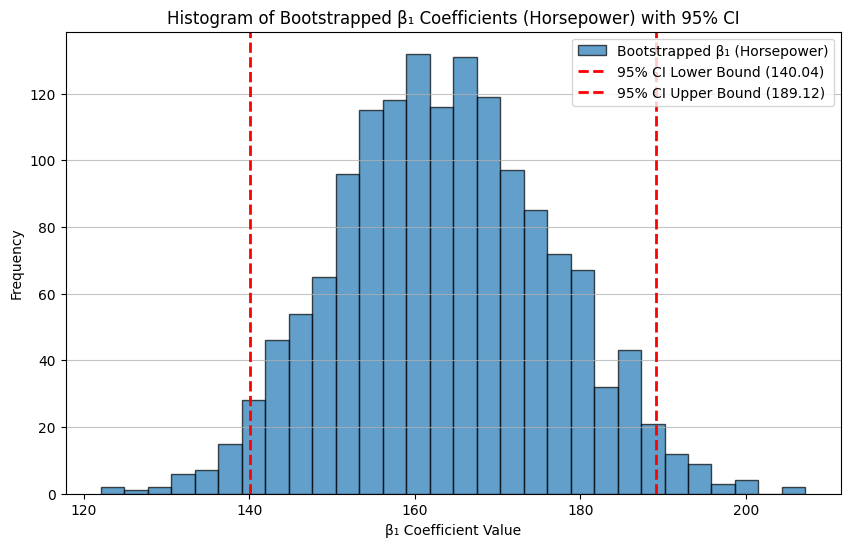

In [25]:
import matplotlib.pyplot as plt

# Plotting the histogram of bootstrapped β₁ values for horsepower
plt.figure(figsize=(10, 6))
plt.hist(beta_horsepower_bootstrap_samples, bins=30, edgecolor='black', alpha=0.7, label='Bootstrapped β₁ (Horsepower)')

# Mark the 95% Confidence Interval bounds
plt.axvline(lower_bound_horsepower, color='red', linestyle='dashed', linewidth=2, label=f'95% CI Lower Bound ({lower_bound_horsepower:.2f})')
plt.axvline(upper_bound_horsepower, color='red', linestyle='dashed', linewidth=2, label=f'95% CI Upper Bound ({upper_bound_horsepower:.2f})')

plt.title('Histogram of Bootstrapped β₁ Coefficients (Horsepower) with 95% CI')
plt.xlabel('β₁ Coefficient Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

In [26]:
import pandas as pd

# Load the dataset
co2_df = pd.read_csv('/content/CO2 Emissions_Canada.csv')

# Select 'Engine Size(L)' as the feature (X)
X_co2 = co2_df[['Engine Size(L)']]
# Select 'CO2 Emissions(g/km)' as the target (y)
y_co2 = co2_df['CO2 Emissions(g/km)']

print("Dataset loaded and features/target selected.")
print("First 5 rows of X_co2 (Engine Size feature):")
display(X_co2.head())
print("First 5 rows of y_co2 (CO2 Emissions target):")
display(y_co2.head())

Dataset loaded and features/target selected.
First 5 rows of X_co2 (Engine Size feature):


,Engine Size(L)
0,2.0
1,2.4
2,1.5
3,3.5
4,3.5


First 5 rows of y_co2 (CO2 Emissions target):


,CO2 Emissions(g/km)
0,196
1,221
2,136
3,255
4,244


In [27]:
from sklearn.linear_model import LinearRegression

# Initialize and fit the Linear Regression model
model_co2 = LinearRegression()
model_co2.fit(X_co2, y_co2)

# Get the coefficient (slope) for 'Engine Size(L)'
beta_engine_size = model_co2.coef_[0]

print(f"Coefficient for Engine Size (β₁): {beta_engine_size:.2f}")

Coefficient for Engine Size (β₁): 36.78


In [28]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Number of bootstrap samples
B = 2000

# List to store bootstrap coefficients for Engine Size
beta_engine_size_bootstrap_samples = []

# Combine X and y for easier sampling
co2_data_for_bootstrap = X_co2.copy()
co2_data_for_bootstrap['CO2 Emissions(g/km)'] = y_co2

# Perform bootstrap resampling
for _ in range(B):
    # Sample with replacement from the combined data
    df_bootstrap_co2 = co2_data_for_bootstrap.sample(n=len(co2_data_for_bootstrap), replace=True)

    # Prepare X and y for the bootstrap sample
    X_bootstrap_co2 = df_bootstrap_co2[['Engine Size(L)']]
    y_bootstrap_co2 = df_bootstrap_co2['CO2 Emissions(g/km)']

    # Initialize and fit the Linear Regression model on the bootstrap sample
    model_bootstrap_co2 = LinearRegression()
    model_bootstrap_co2.fit(X_bootstrap_co2, y_bootstrap_co2)

    # Store the coefficient for Engine Size
    beta_engine_size_bootstrap_samples.append(model_bootstrap_co2.coef_[0])

print(f"Collected {len(beta_engine_size_bootstrap_samples)} bootstrap samples of β₁ (Engine Size).")

# Compute the 90% confidence interval for β₁ (Engine Size) using the percentile method
lower_bound_90_co2 = np.percentile(beta_engine_size_bootstrap_samples, 5)
upper_bound_90_co2 = np.percentile(beta_engine_size_bootstrap_samples, 95)

print(f"90% Confidence Interval for Engine Size Coefficient (β₁): ({lower_bound_90_co2:.2f}, {upper_bound_90_co2:.2f})")

# Compute the 95% confidence interval for β₁ (Engine Size) using the percentile method
lower_bound_95_co2 = np.percentile(beta_engine_size_bootstrap_samples, 2.5)
upper_bound_95_co2 = np.percentile(beta_engine_size_bootstrap_samples, 97.5)

print(f"95% Confidence Interval for Engine Size Coefficient (β₁): ({lower_bound_95_co2:.2f}, {upper_bound_95_co2:.2f})")

Collected 2000 bootstrap samples of β₁ (Engine Size).
90% Confidence Interval for Engine Size Coefficient (β₁): (36.28, 37.29)
95% Confidence Interval for Engine Size Coefficient (β₁): (36.19, 37.40)


In [29]:
# Compare the 90% and 95% confidence intervals for β₁ (Engine Size)
print(f"90% Confidence Interval for Engine Size Coefficient (β₁): ({lower_bound_90_co2:.2f}, {upper_bound_90_co2:.2f})")
print(f"95% Confidence Interval for Engine Size Coefficient (β₁): ({lower_bound_95_co2:.2f}, {upper_bound_95_co2:.2f})")

print("\nComparison: The 95% confidence interval is wider than the 90% confidence interval. This is expected, as a higher confidence level requires a broader range to encompass the true parameter with greater certainty.")

90% Confidence Interval for Engine Size Coefficient (β₁): (36.28, 37.29)
95% Confidence Interval for Engine Size Coefficient (β₁): (36.19, 37.40)

Comparison: The 95% confidence interval is wider than the 90% confidence interval. This is expected, as a higher confidence level requires a broader range to encompass the true parameter with greater certainty.


In [30]:
# Conclude whether engine size significantly affects CO₂ emissions

# Review the previously calculated confidence intervals:
# 90% Confidence Interval for Engine Size Coefficient (β₁): (36.28, 37.29)
# 95% Confidence Interval for Engine Size Coefficient (β₁): (36.19, 37.40)

print("\nConclusion on the effect of Engine Size on CO₂ Emissions:")
print("----------------------------------------------------------")

# Check if the confidence intervals contain zero
if lower_bound_95_co2 > 0 or upper_bound_95_co2 < 0:
    print(f"Both the 90% CI ({lower_bound_90_co2:.2f}, {upper_bound_90_co2:.2f}) and the 95% CI ({lower_bound_95_co2:.2f}, {upper_bound_95_co2:.2f}) for the β₁ coefficient of 'Engine Size(L)' do not include zero.")
    print("Therefore, we can conclude with high statistical confidence that engine size significantly affects CO₂ emissions.")
    print("The positive values of the coefficient indicate a statistically significant positive relationship: as engine size increases, CO₂ emissions tend to increase.")
else:
    print(f"The 95% Confidence Interval ({lower_bound_95_co2:.2f}, {upper_bound_95_co2:.2f}) includes zero. Therefore, we cannot conclude that engine size significantly affects CO₂ emissions at the 95% confidence level.")


Conclusion on the effect of Engine Size on CO₂ Emissions:
----------------------------------------------------------
Both the 90% CI (36.28, 37.29) and the 95% CI (36.19, 37.40) for the β₁ coefficient of 'Engine Size(L)' do not include zero.
Therefore, we can conclude with high statistical confidence that engine size significantly affects CO₂ emissions.
The positive values of the coefficient indicate a statistically significant positive relationship: as engine size increases, CO₂ emissions tend to increase.
